In [8]:
import baostock as bs

In [2]:
import pandas as pd

In [9]:
stock_df = ak.stock_zh_a_hist(symbol="000001", period="daily", start_date="20240101", adjust="qfq")
print("环境配置成功！数据前 5 行如下：")
print(stock_df.head())

ProxyError: HTTPSConnectionPool(host='push2his.eastmoney.com', port=443): Max retries exceeded with url: /api/qt/stock/kline/get?fields1=f1%2Cf2%2Cf3%2Cf4%2Cf5%2Cf6&fields2=f51%2Cf52%2Cf53%2Cf54%2Cf55%2Cf56%2Cf57%2Cf58%2Cf59%2Cf60%2Cf61%2Cf116&ut=7eea3edcaed734bea9cbfc24409ed989&klt=101&fqt=1&secid=0.000001&beg=20240101&end=20500101 (Caused by ProxyError('Unable to connect to proxy', RemoteDisconnected('Remote end closed connection without response')))

In [7]:
!pip install baostock -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [10]:
lg = bs.login()

login success!


In [11]:
rs = bs.query_history_k_data_plus(
    "sz.000001",
    "date,code,open,high,low,close,preclose,volume,amount",
    start_date='2024-01-01', 
    end_date='2024-03-01',
    frequency="d", 
    adjustflag="3" # 3:不复权，1:后复权，2:前复权
)

In [12]:
data_list = []
while (rs.error_code == '0') & rs.next():
    data_list.append(rs.get_row_data())

result = pd.DataFrame(data_list, columns=rs.fields)

In [13]:
bs.logout()

logout success!


In [14]:
print("Baostock 环境配置完全成功！数据前 5 行如下：")
print(result.head())

Baostock 环境配置完全成功！数据前 5 行如下：
         date       code    open    high     low   close preclose     volume  \
0  2024-01-02  sz.000001  9.3900  9.4200  9.2100  9.2100   9.3900  115836645   
1  2024-01-03  sz.000001  9.1900  9.2200  9.1500  9.2000   9.2100   73361031   
2  2024-01-04  sz.000001  9.1900  9.1900  9.0800  9.1100   9.2000   86419399   
3  2024-01-05  sz.000001  9.1000  9.4400  9.0700  9.2700   9.1100  199162216   
4  2024-01-08  sz.000001  9.2300  9.3000  9.1100  9.1500   9.2700  112115619   

            amount  
0  1075742252.4500  
1   673673613.5400  
2   787470082.3700  
3  1852659692.1400  
4  1029006548.7300  


In [18]:
# ========== 补充 1：考虑实际交易手续费（假设单边万分之五） ==========
fee = 0.0005  # 万分之五佣金/印花税折算
# 调仓信号：今天信号跟昨天不一样，说明发生了买卖
df["trade_quant"] = df["signal_quant"].diff().abs().fillna(0)
# 扣除手续费后的真实日收益
df["ret_quant_real"] = df["ret_quant"] - df["trade_quant"] * fee
df["nav_ret_quant_real"] = (1 + df["ret_quant_real"]).cumprod()

# ========== 补充 2：计算核心评估指标（以量化真实策略为例） ==========
def calc_metrics(nav_series):
    # 1. 累计收益率
    total_return = nav_series.iloc[-1] - 1
    # 2. 最大回撤
    cummax = nav_series.cummax()
    drawdown = (nav_series - cummax) / cummax
    max_drawdown = drawdown.min()
    return total_return, max_drawdown

tot_ret, max_dd = calc_metrics(df["nav_ret_quant_real"])
print(f"--- 真实量化策略表现 ---")
print(f"累计收益率: {tot_ret*100:.2f}%")
print(f"最大回撤: {max_dd*100:.2f}%")

--- 真实量化策略表现 ---
累计收益率: -6.87%
最大回撤: -13.53%


--- 扣费后真实量化策略表现 ---
累计收益率: -6.87%
最大回撤: -13.53%


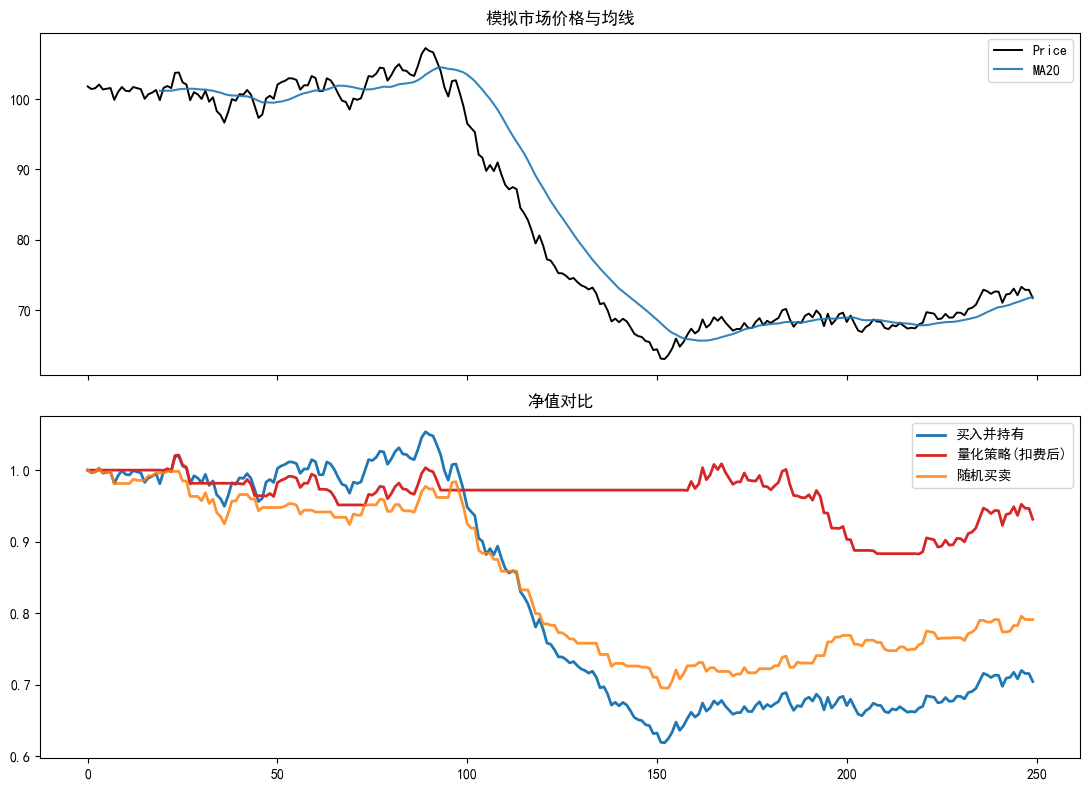

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========== 1. 基础数据与策略生成 ==========
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(7)

n1, n2, n3 = 90, 40, 120
ret = np.r_[
    np.random.normal(0.0010, 0.010, n1),
    np.random.normal(-0.012, 0.015, n2),
    np.random.normal(0.0012, 0.012, n3)
]
price = 100 * np.cumprod(1 + ret)

df = pd.DataFrame({"close": price})
df["ret"] = df["close"].pct_change().fillna(0)
df["ma20"] = df["close"].rolling(20).mean()
df["signal_quant"] = (df["close"] > df["ma20"]).astype(int)

rng = np.random.default_rng(7)
df["signal_random"] = rng.integers(0, 2, size=len(df))

df["ret_quant"] = df["signal_quant"].shift(1).fillna(0) * df["ret"]
df["ret_random"] = df["signal_random"].shift(1).fillna(0) * df["ret"]
df["ret_buyhold"] = df["ret"]

# ========== 2. 扣除交易手续费（扣费版） ==========
fee = 0.0005  # 万分之五佣金/印花税
df["trade_quant"] = df["signal_quant"].diff().abs().fillna(0)
df["ret_quant_real"] = df["ret_quant"] - df["trade_quant"] * fee

# ========== 3. 计算净值 ==========
for col in ["ret_quant", "ret_quant_real", "ret_random", "ret_buyhold"]:
    df[f"nav_{col}"] = (1 + df[col]).cumprod()

# ========== 4. 评估指标与画图 ==========
def calc_metrics(nav_series):
    tot_ret = nav_series.iloc[-1] - 1
    cummax = nav_series.cummax()
    max_dd = ((nav_series - cummax) / cummax).min()
    return tot_ret, max_dd

tot_ret, max_dd = calc_metrics(df["nav_ret_quant_real"])
print(f"--- 扣费后真实量化策略表现 ---")
print(f"累计收益率: {tot_ret*100:.2f}%")
print(f"最大回撤: {max_dd*100:.2f}%")

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].plot(df["close"], label="Price", color="black", linewidth=1.4)
axes[0].plot(df["ma20"], label="MA20", color="tab:blue", alpha=0.9)
axes[0].set_title("模拟市场价格与均线")
axes[0].legend()

axes[1].plot(df["nav_ret_buyhold"], label="买入并持有", linewidth=2)
axes[1].plot(df["nav_ret_quant_real"], label="量化策略(扣费后)", linewidth=2, color="tab:red")
axes[1].plot(df["nav_ret_random"], label="随机买卖", linewidth=2, alpha=0.85)
axes[1].set_title("净值对比")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
!pip install scipy statsmodels scikit-learn seaborn ta mplfinance -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
     - -------------------------------------- 1.0/41.3 MB 6.3 MB/s eta 0:00:07
     --- ------------------------------------ 3.1/41.3 MB 7.7 MB/s eta 0:00:05
     ----- ---------------------------------- 5.5/41.3 MB 9.1 MB/s eta 0:00:04
     ------- -------------------------------- 7.6/41.3 MB 9.4 MB/s eta 0:00:04
     ------- -------------------------------- 8.1/41.3 MB 9.3 MB/s eta 0:00:04
     ---------- ----------------------------- 11.3/41.3 MB 9.0 MB/s eta 0:00:04
     ---------- ----------------------------- 11.3/41.3 MB 9.0 MB/s eta 0:00:04
     ------------ --------------------------- 13.1/41.3 MB 8.0 MB/s eta 0:00:04
     ------------ --------------------------- 13.1/41.3 MB 8.0 MB/s eta 0:00:04
     ------------ --------------------------- 13.4/41.3 MB 6.7 MB/s eta 0:00:05
     ------------- -------------------------- 14.2/41.3 MB 6.2 MB/s eta 

In [23]:
!pip install yfinance -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

   -------- ------------------------------- 1/5 [websockets]
   -------- ------------------------------- 1/5 [websockets]
   -------- ------------------------------- 1/5 [websockets]
   -------- ------------------------------- 1/5 [websockets]
   -------- ------------------------------- 1/5 [websockets]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ------------------------ --------------- 3/5 [peewee]
   ------------------------ --------------- 3/5 [peewee]
   ------------------------ --------------- 3/5 [peewee]
   ------------------------ --------------- 3/5 [

In [32]:
!pip install --upgrade yfinance curl_cffi -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


🎉 恭喜！你已经拿到真实股票数据
共 125 个交易日
最新收盘价: $nan


,Close,High,Low,Open,Volume
Date,,,,,
2026-08-11,304.910004,309.970001,302.790009,307.750000,37476700
2026-08-12,302.250000,305.660004,300.570007,305.100006,41657800
2026-08-13,305.260010,306.000000,302.049988,304.209991,40349300
2026-08-14,305.929993,307.489990,304.299988,306.000000,28229400
2026-08-17,NaN,NaN,NaN,NaN,32743947


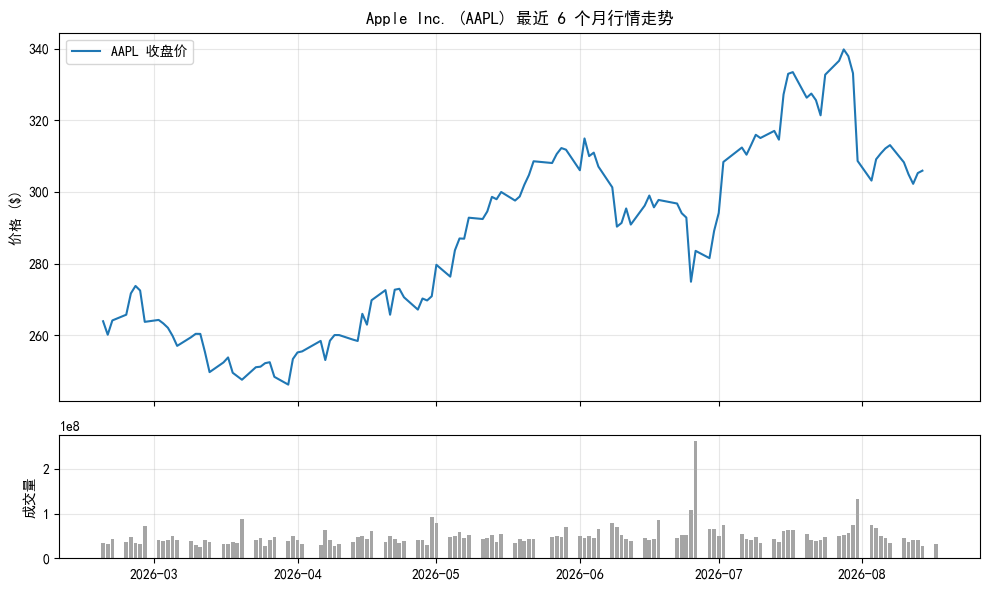

In [38]:
import os
import yfinance as yf
import matplotlib.pyplot as plt

# 1. 设置画图中文支持
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 配置本地代理端口
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

# 3. 下载 AAPL 数据（添加 multi_level_index=False 避免多层索引嵌套）
aapl = yf.download('AAPL', period='6mo', progress=False, multi_level_index=False)

# 4. 提取最新收盘价并转为 float 纯数值打印
latest_close = float(aapl['Close'].iloc[-1])

print('🎉 恭喜！你已经拿到真实股票数据')
print(f'共 {len(aapl)} 个交易日')
print(f"最新收盘价: ${latest_close:.2f}")
display(aapl.tail(5))

# 5. 绘制收盘价与成交量走势图
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# 上图：收盘价
axes[0].plot(aapl.index, aapl['Close'], color='tab:blue', linewidth=1.5, label='AAPL 收盘价')
axes[0].set_title('Apple Inc. (AAPL) 最近 6 个月行情走势')
axes[0].set_ylabel('价格 ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 下图：成交量
axes[1].bar(aapl.index, aapl['Volume'], color='tab:gray', alpha=0.7, label='成交量')
axes[1].set_ylabel('成交量')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🎉 恭喜！你已经拿到真实股票数据
共 125 个交易日
最新收盘价: $nan


,Close,High,Low,Open,Volume
Date,,,,,
2026-08-11,868.520020,879.000000,844.619995,871.799988,29438300
2026-08-12,911.289978,935.799988,899.539978,912.940002,36804900
2026-08-13,949.830017,978.000000,906.500000,912.890015,36704700
2026-08-14,971.659973,984.000000,956.200012,979.320007,27881100
2026-08-17,NaN,NaN,NaN,NaN,33067341


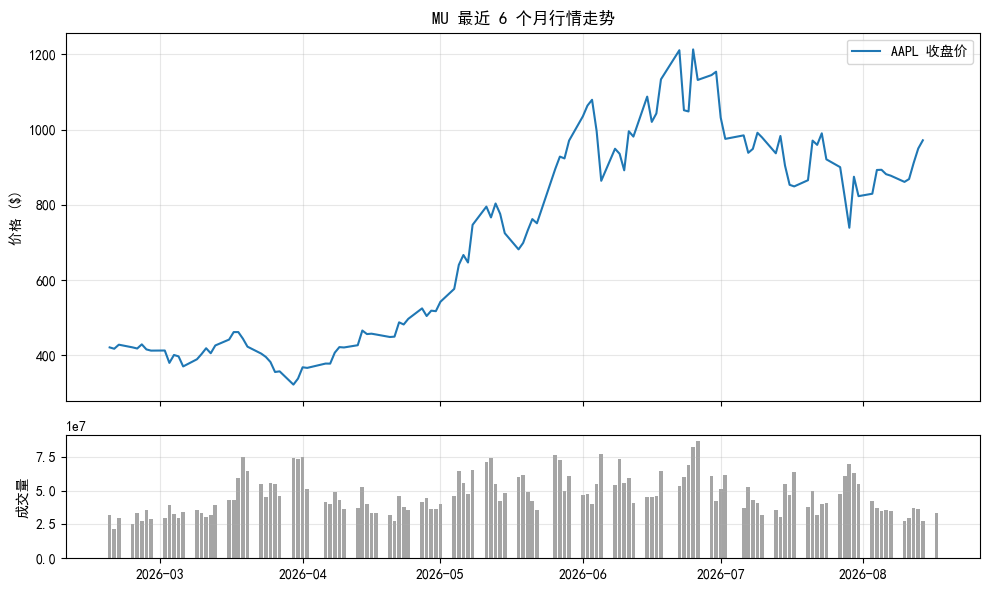

In [40]:
import os
import yfinance as yf
import matplotlib.pyplot as plt

# 1. 设置画图中文支持
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 配置本地代理端口
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

# 3. 下载 AAPL 数据（添加 multi_level_index=False 避免多层索引嵌套）
aapl = yf.download('MU', period='6mo', progress=False, multi_level_index=False)

# 4. 提取最新收盘价并转为 float 纯数值打印
latest_close = float(aapl['Close'].iloc[-1])

print('🎉 恭喜！你已经拿到真实股票数据')
print(f'共 {len(aapl)} 个交易日')
print(f"最新收盘价: ${latest_close:.2f}")
display(aapl.tail(5))

# 5. 绘制收盘价与成交量走势图
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# 上图：收盘价
axes[0].plot(aapl.index, aapl['Close'], color='tab:blue', linewidth=1.5, label='AAPL 收盘价')
axes[0].set_title('MU 最近 6 个月行情走势')
axes[0].set_ylabel('价格 ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 下图：成交量
axes[1].bar(aapl.index, aapl['Volume'], color='tab:gray', alpha=0.7, label='成交量')
axes[1].set_ylabel('成交量')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
aapl['Volume'].idxmax()

Timestamp('2026-06-26 00:00:00')

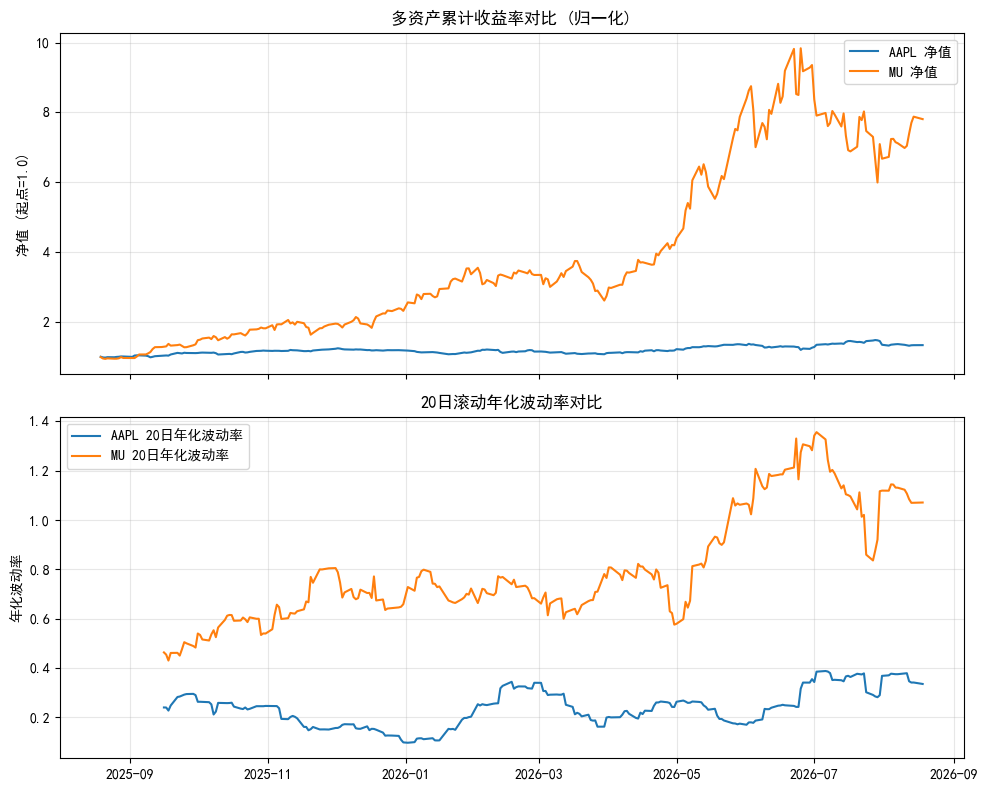

=== 资产统计指标 ===
           年化收益率     年化波动率  日收益偏度 (Skew)  日收益峰度 (Kurt)
Ticker                                                
AAPL    0.334208  0.250245     -0.406279      3.186548
MU      6.935917  0.811333      0.305888      1.042896


In [42]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 代理与画图配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 多标的下载 (以 AAPL 和 MU 为例)
tickers = ['AAPL', 'MU']
data = yf.download(tickers, period='1y', progress=False)['Close']

# 3. 计算收益率与波动率特征
returns = data.pct_change().dropna()

# 归一化累计净值 (起点设为 1)
cum_returns = (1 + returns).cumprod()

# 计算 20 日滚动年化波动率
vol_20d = returns.rolling(20).std() * np.sqrt(252)

# 4. 可视化实验对比
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 上图：累计收益走势对比
axes[0].plot(cum_returns.index, cum_returns['AAPL'], label='AAPL 净值', color='tab:blue')
axes[0].plot(cum_returns.index, cum_returns['MU'], label='MU 净值', color='tab:orange')
axes[0].set_title('多资产累计收益率对比 (归一化)')
axes[0].set_ylabel('净值 (起点=1.0)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 下图：滚动年化波动率对比
axes[1].plot(vol_20d.index, vol_20d['AAPL'], label='AAPL 20日年化波动率', color='tab:blue')
axes[1].plot(vol_20d.index, vol_20d['MU'], label='MU 20日年化波动率', color='tab:orange')
axes[1].set_title('20日滚动年化波动率对比')
axes[1].set_ylabel('年化波动率')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. 打印统计特征对比
print("=== 资产统计指标 ===")
stats = pd.DataFrame({
    '年化收益率': (cum_returns.iloc[-1] ** (252 / len(returns))) - 1,
    '年化波动率': returns.std() * np.sqrt(252),
    '日收益偏度 (Skew)': returns.skew(),
    '日收益峰度 (Kurt)': returns.kurt()
})
print(stats)

In [43]:
import os
import yfinance as yf
import pandas as pd
import numpy as np

# 1. 代理与下载 AAPL 数据
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

df = yf.download('AAPL', period='6mo', progress=False, multi_level_index=False)

# 2. 批量构建 OHLCV 衍生特征
# (1) 日内振幅
df['amplitude'] = (df['High'] - df['Low']) / df['Close'].shift(1)

# (2) 实体占比
df['body_ratio'] = (df['Close'] - df['Open']).abs() / (df['High'] - df['Low'])

# (3) 真实波幅 (TR)
tr1 = df['High'] - df['Low']
tr2 = (df['High'] - df['Close'].shift(1)).abs()
tr3 = (df['Low'] - df['Close'].shift(1)).abs()
df['true_range'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# (4) 量比 (5日)
df['vol_ratio'] = df['Volume'] / df['Volume'].rolling(5).mean()

# 3. 查看前 5 行计算结果
cols_to_show = ['Close', 'Volume', 'amplitude', 'body_ratio', 'true_range', 'vol_ratio']
print(df[cols_to_show].dropna().head())

                 Close    Volume  amplitude  body_ratio  true_range  vol_ratio
Date                                                                          
2026-02-24  271.655243  47014600   0.026974    0.596102    8.694534   1.227908
2026-02-25  273.741516  33714300   0.014294    0.629821    3.883085   0.882791
2026-02-26  272.463776  32345100   0.019363    0.376648    5.300538   0.840339
2026-02-27  263.709381  72366500   0.036344    0.869962   10.042075   1.624398
2026-03-02  264.248413  41827900   0.023961    0.364929    6.318710   0.920231


In [44]:
import os
import yfinance as yf
import pandas as pd
import numpy as np

# 1. 代理与环境配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

# 2. 获取包含 2024-06-10 及前序交易日的数据（用于计算前日收盘价与5日均量）
df = yf.download('AAPL', start='2024-05-20', end='2024-06-15', progress=False, multi_level_index=False)

# 3. 计算 5 项 OHLCV 衍生特征
# (1) 日内振幅 (Amplitude)
df['amplitude'] = (df['High'] - df['Low']) / df['Close'].shift(1) * 100

# (2) K线实体变化率与占比 (Body Ratio)
df['body_pct'] = (df['Close'] - df['Open']).abs() / df['Open'] * 100
df['body_ratio'] = (df['Close'] - df['Open']).abs() / (df['High'] - df['Low']) * 100

# (3) 上下影线特征 (Upper & Lower Shadows)
df['upper_shadow'] = df['High'] - np.maximum(df['Open'], df['Close'])
df['lower_shadow'] = np.minimum(df['Open'], df['Close']) - df['Low']
df['upper_shadow_ratio'] = df['upper_shadow'] / (df['High'] - df['Low']) * 100
df['lower_shadow_ratio'] = df['lower_shadow'] / (df['High'] - df['Low']) * 100

# (4) 真实波幅 (True Range, TR)
tr1 = df['High'] - df['Low']
tr2 = (df['High'] - df['Close'].shift(1)).abs()
tr3 = (df['Low'] - df['Close'].shift(1)).abs()
df['true_range'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# (5) 量比 (Volume Ratio，以过去5日均量为基准)
df['vol_ma5'] = df['Volume'].shift(1).rolling(5).mean()
df['vol_ratio'] = df['Volume'] / df['vol_ma5']

# 4. 提取 2024-06-10 当天数据并格式化输出
target_date = "2024-06-10"
row = df.loc[target_date]

print(f"=== 苹果公司 (AAPL) {target_date} WWDC 当日行情 ===")
print(f"开盘价 (Open):   ${row['Open']:.2f}")
print(f"最高价 (High):   ${row['High']:.2f}")
print(f"最低价 (Low):    ${row['Low']:.2f}")
print(f"收盘价 (Close):  ${row['Close']:.2f}")
print(f"成交量 (Volume): {int(row['Volume']):,} 股")

print("\n=== 5 大 OHLCV 衍生特征计算结果 ===")
print(f"1. 日内振幅 (Amplitude):       {row['amplitude']:.2f}%")
print(f"2. 实体占总波幅比例 (Body Ratio): {row['body_ratio']:.2f}% (实体幅度: {row['body_pct']:.2f}%)")
print(f"3. 影线特征 (Shadows):")
print(f"   - 上影线: ${row['upper_shadow']:.2f} (占波幅 {row['upper_shadow_ratio']:.2f}%)")
print(f"   - 下影线: ${row['lower_shadow']:.2f} (占波幅 {row['lower_shadow_ratio']:.2f}%)")
print(f"4. 真实波幅 (True Range):       ${row['true_range']:.2f}")
print(f"5. 5日相对量比 (Volume Ratio):   {row['vol_ratio']:.2f} 倍")

=== 苹果公司 (AAPL) 2024-06-10 WWDC 当日行情 ===
开盘价 (Open):   $195.04
最高价 (High):   $195.44
最低价 (Low):    $190.34
收盘价 (Close):  $191.30
成交量 (Volume): 97,010,200 股

=== 5 大 OHLCV 衍生特征计算结果 ===
1. 日内振幅 (Amplitude):       2.62%
2. 实体占总波幅比例 (Body Ratio): 73.40% (实体幅度: 1.92%)
3. 影线特征 (Shadows):
   - 上影线: $0.40 (占波幅 7.77%)
   - 下影线: $0.96 (占波幅 18.83%)
4. 真实波幅 (True Range):       $5.10
5. 5日相对量比 (Volume Ratio):   1.97 倍


In [47]:
import os
import yfinance as yf
import pandas as pd
import numpy as np

# 1. 代理配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

# 2. 下载美光科技 (MU) 数据
df = yf.download('MU', start='2024-03-01', end='2024-03-26', progress=False, multi_level_index=False)
df.index = df.index.tz_localize(None)

# 3. 计算日内基础与影线特征
# 上影线与下影线
df['upper_shadow'] = df['High'] - np.maximum(df['Open'], df['Close'])
df['lower_shadow'] = np.minimum(df['Open'], df['Close']) - df['Low']
df['range'] = df['High'] - df['Low']
df['upper_shadow_ratio'] = (df['upper_shadow'] / df['range']) * 100
df['lower_shadow_ratio'] = (df['lower_shadow'] / df['range']) * 100

# 真实波幅 (TR)
tr1 = df['High'] - df['Low']
tr2 = (df['High'] - df['Close'].shift(1)).abs()
tr3 = (df['Low'] - df['Close'].shift(1)).abs()
df['true_range'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# 5日相对量比
df['vol_ma5'] = df['Volume'].shift(1).rolling(5).mean()
df['vol_ratio'] = df['Volume'] / df['vol_ma5']

# 4. 提取 2024-03-21 当天结果
target_date = "2024-03-21"
row = df.loc[target_date]
prev_close = df['Close'].shift(1).loc[target_date]

print(f"=== 美光科技 (MU) {target_date} 财报当日行情 ===")
print(f"昨日收盘 (Prev Close): ${prev_close:.2f}")
print(f"今日开盘 (Open):       ${row['Open']:.2f} (跳空高开: +{(row['Open']/prev_close - 1)*100:.2f}%)")
print(f"今日最高 (High):       ${row['High']:.2f}")
print(f"今日最低 (Low):        ${row['Low']:.2f}")
print(f"今日收盘 (Close):      ${row['Close']:.2f} (单日涨幅: +{(row['Close']/prev_close - 1)*100:.2f}%)")
print(f"今日成交量:            {int(row['Volume']):,} 股")

print("\n=== 全套衍生特征计算 ===")
print(f"1. 5日相对量比:   {row['vol_ratio']:.2f} 倍")
print(f"2. 真实波幅 (TR): ${row['true_range']:.2f}")
print(f"3. 影线分析:")
print(f"   - 上影线: ${row['upper_shadow']:.2f} (占当日波幅 {row['upper_shadow_ratio']:.2f}%)")
print(f"   - 下影线: ${row['lower_shadow']:.2f} (占当日波幅 {row['lower_shadow_ratio']:.2f}%)")

=== 美光科技 (MU) 2024-03-21 财报当日行情 ===
昨日收盘 (Prev Close): $95.47
今日开盘 (Open):       $112.45 (跳空高开: +17.79%)
今日最高 (High):       $112.58
今日最低 (Low):        $107.90
今日收盘 (Close):      $108.96 (单日涨幅: +14.13%)
今日成交量:            89,554,100 股

=== 全套衍生特征计算 ===
1. 5日相对量比:   3.44 倍
2. 真实波幅 (TR): $17.11
3. 影线分析:
   - 上影线: $0.13 (占当日波幅 2.75%)
   - 下影线: $1.06 (占当日波幅 22.67%)


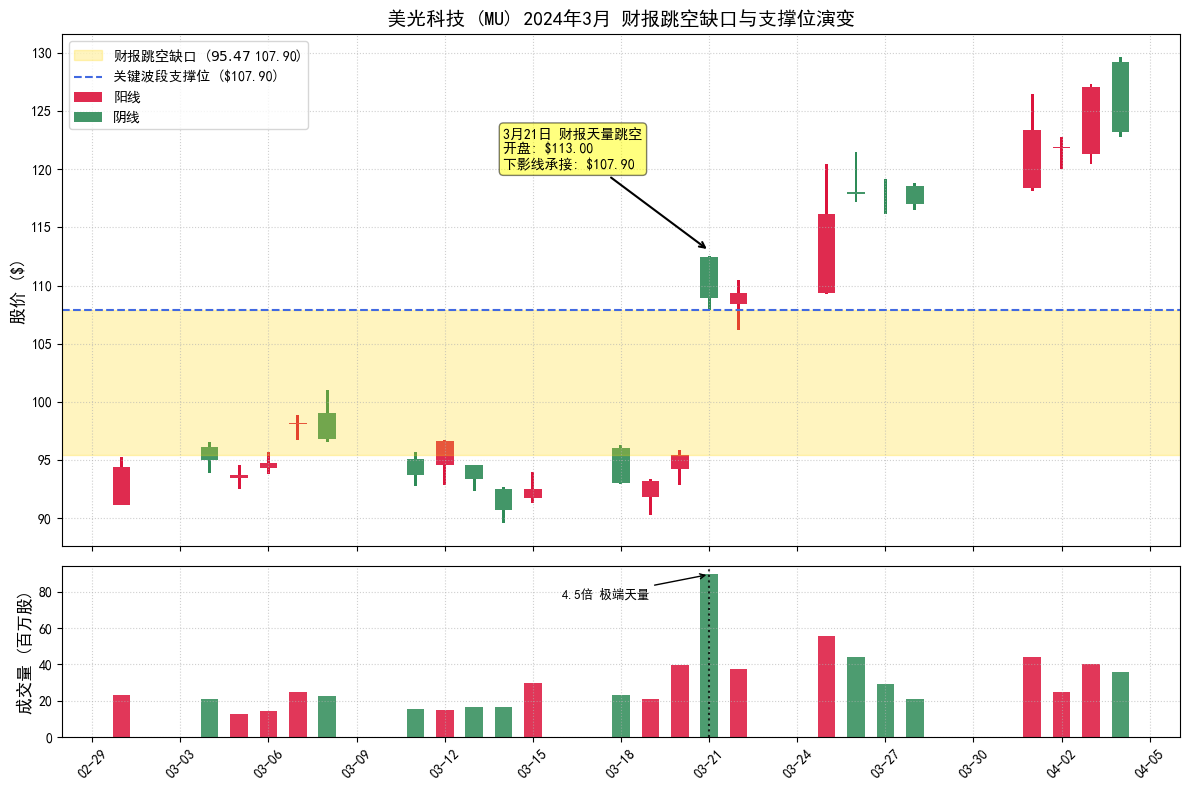

In [49]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 代理与中文显示配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 下载美光科技 (MU) 2024 年 3 月全月及前后数据
df = yf.download('MU', start='2024-03-01', end='2024-04-05', progress=False, multi_level_index=False)
df.index = df.index.tz_localize(None)

# 3. 提取关键价格位
# 3月20日（财报前一日收盘）与 3月21日（跳空当日最低与收盘）
gap_bottom = df.loc['2024-03-20', 'Close']   # 缺口下沿：约 $96.25
gap_top = df.loc['2024-03-21', 'Low']        # 缺口上沿/日内支撑：约 $108.58
target_date = pd.to_datetime('2024-03-21')

# 4. 创建画板 (价格主图 + 成交量子图)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- 上图：K 线绘制与缺口/支撑标注 ---
# 绘制简易 K 线（阳线红色，阴线绿色）
width = 0.6
width2 = 0.1
up = df[df.Close >= df.Open]
down = df[df.Close < df.Open]

# 阳线
axes[0].bar(up.index, up.Close - up.Open, width, bottom=up.Open, color='crimson', alpha=0.9, label='阳线')
axes[0].bar(up.index, up.High - up.Close, width2, bottom=up.Close, color='crimson')
axes[0].bar(up.index, up.Low - up.Open, width2, bottom=up.Open, color='crimson')

# 阴线
axes[0].bar(down.index, down.Close - down.Open, width, bottom=down.Open, color='seagreen', alpha=0.9, label='阴线')
axes[0].bar(down.index, down.High - down.Open, width2, bottom=down.Open, color='seagreen')
axes[0].bar(down.index, down.Low - down.Close, width2, bottom=down.Close, color='seagreen')

# 绘制跳空缺口阴影区域 ($96.25 ~ $108.58)
axes[0].axhspan(gap_bottom, gap_top, color='gold', alpha=0.25, label=f'财报跳空缺口 (${gap_bottom:.2f} ~ ${gap_top:.2f})')

# 绘制关键支撑线（3月21日低点 $108.58）
axes[0].axhline(y=gap_top, color='royalblue', linestyle='--', linewidth=1.5, label=f'关键波段支撑位 (${gap_top:.2f})')

# 箭头标注 3 月 21 日财报跳空位置
axes[0].annotate(
    f'3月21日 财报天量跳空\n开盘: $113.00\n下影线承接: ${gap_top:.2f}',
    xy=(mdates.date2num(target_date), 113.00),
    xytext=(mdates.date2num(target_date) - 7, 120),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5)
)

axes[0].set_title('美光科技 (MU) 2024年3月 财报跳空缺口与支撑位演变', fontsize=14)
axes[0].set_ylabel('股价 ($)', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left')

# --- 下图：成交量对比 ---
vol_colors = ['crimson' if c >= o else 'seagreen' for c, o in zip(df.Close, df.Open)]
axes[1].bar(df.index, df['Volume'] / 1e6, color=vol_colors, width=width, alpha=0.85)
axes[1].axvline(x=target_date, color='black', linestyle=':', alpha=0.8)
axes[1].annotate('4.5倍 极端天量', xy=(mdates.date2num(target_date), df.loc['2024-03-21', 'Volume']/1e6),
                xytext=(mdates.date2num(target_date) - 5, (df.loc['2024-03-21', 'Volume']/1e6)*0.85),
                arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)

axes[1].set_ylabel('成交量 (百万股)', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)

# 格式化日期轴
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [50]:
import os
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 代理与中文配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 下载 2024-03-22 当天 5 分钟高频分时数据
ticker = yf.Ticker('MU')
# 获取包含 3月22日的分时数据
df_intraday = ticker.history(start='2024-03-22', end='2024-03-23', interval='5m')

if not df_intraday.empty:
    # 3. 绘制分时走势图
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(df_intraday.index, df_intraday['Close'], color='tab:blue', lw=2, label='5分钟收盘价')
    ax.scatter(df_intraday.index[0], df_intraday['Open'].iloc[0], color='black', s=80, zorder=5, label=f"开盘: ${df_intraday['Open'].iloc[0]:.2f}")
    ax.scatter(df_intraday['High'].idxmax(), df_intraday['High'].max(), color='red', s=80, zorder=5, label=f"盘中最高: ${df_intraday['High'].max():.2f}")
    ax.scatter(df_intraday['Low'].idxmin(), df_intraday['Low'].min(), color='green', s=80, zorder=5, label=f"盘中最低: ${df_intraday['Low'].min():.2f}")
    ax.scatter(df_intraday.index[-1], df_intraday['Close'].iloc[-1], color='purple', s=80, zorder=5, label=f"收盘: ${df_intraday['Close'].iloc[-1]:.2f}")

    ax.set_title('美光科技 (MU) 2024-03-22 5分钟级别日内完整走势', fontsize=13)
    ax.set_ylabel('价格 ($)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print("雅虎财经免费接口仅保留近期的历史高频分时数据。")

$MU: 5m data not available for startTime=1711080000 and endTime=1711166400. The requested range must be within the last 60 days.


雅虎财经免费接口仅保留近期的历史高频分时数据。


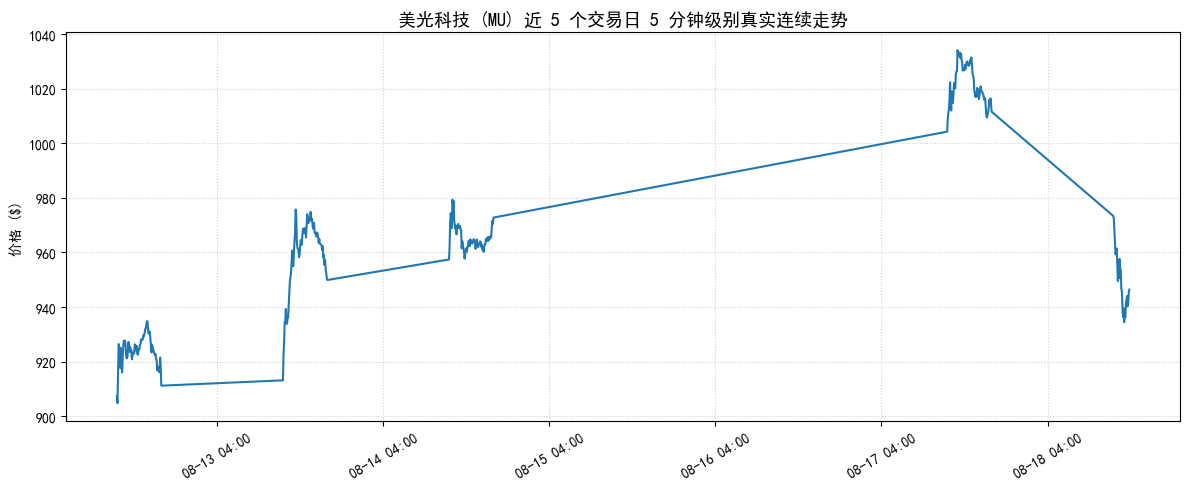

In [51]:
import os
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 代理与画图配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 下载美光科技 (MU) 最近 5 天的 5 分钟高频分时数据
ticker = yf.Ticker('MU')
df_recent = ticker.history(period='5d', interval='5m')

if not df_recent.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df_recent.index, df_recent['Close'], color='tab:blue', lw=1.5, label='5分钟收盘价')
    ax.set_title('美光科技 (MU) 近 5 个交易日 5 分钟级别真实连续走势', fontsize=13)
    ax.set_ylabel('价格 ($)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

$MU: possibly delisted; no price data found  (period=1y)
$AAPL: possibly delisted; no price data found  (period=1y)

2 Failed downloads:
['MU', 'AAPL']: possibly delisted; no price data found  (period=1y)


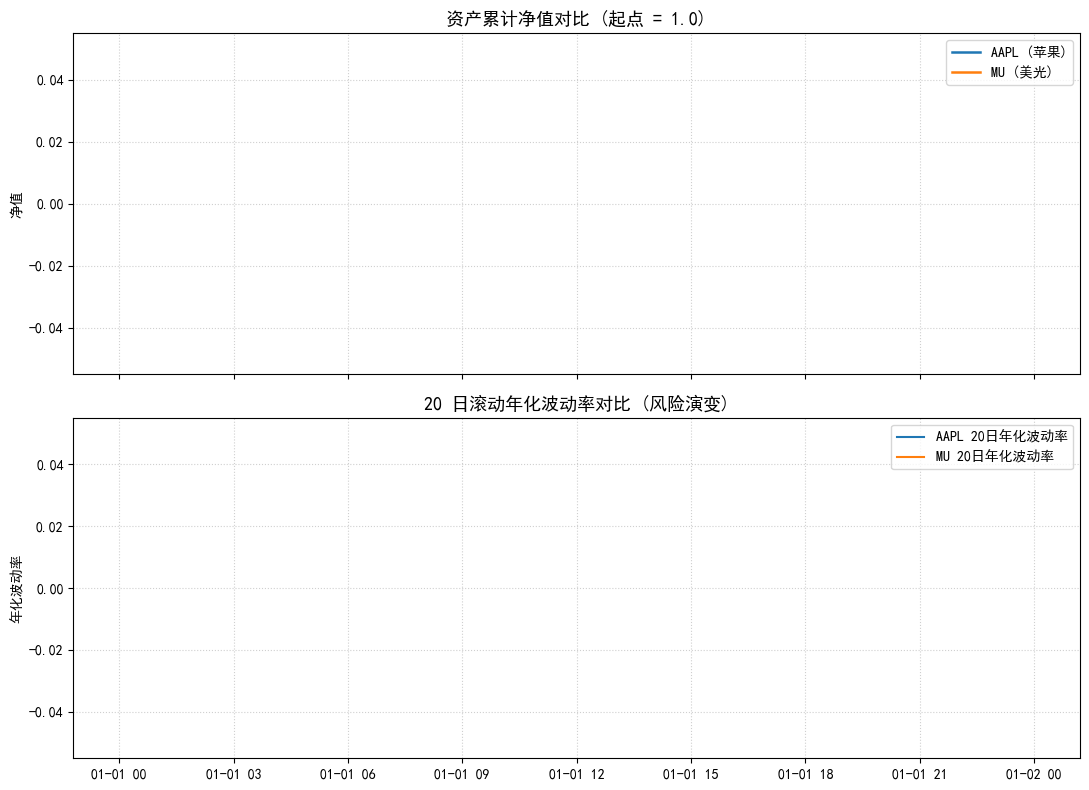

IndexError: single positional indexer is out-of-bounds

In [53]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 代理与画图配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 批量下载数据 (取最近 1 年)
tickers = ['AAPL', 'MU']
df = yf.download(tickers, period='1y', progress=False)['Close']
df = df.dropna()

# 3. 计算简单收益率与对数收益率
returns = df.pct_change().dropna()
log_returns = np.log(df / df.shift(1)).dropna()

# 4. 计算归一化净值 (起点设为 1.0)
cum_returns = (1 + returns).cumprod()

# 5. 计算 20 日滚动年化波动率
vol_20d = returns.rolling(20).std() * np.sqrt(252)

# 6. 可视化对比
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# 净值走势对比
axes[0].plot(cum_returns.index, cum_returns['AAPL'], label='AAPL (苹果)', color='tab:blue', lw=1.8)
axes[0].plot(cum_returns.index, cum_returns['MU'], label='MU (美光)', color='tab:orange', lw=1.8)
axes[0].set_title('资产累计净值对比 (起点 = 1.0)', fontsize=13)
axes[0].set_ylabel('净值')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# 滚动波动率对比
axes[1].plot(vol_20d.index, vol_20d['AAPL'], label='AAPL 20日年化波动率', color='tab:blue', lw=1.5)
axes[1].plot(vol_20d.index, vol_20d['MU'], label='MU 20日年化波动率', color='tab:orange', lw=1.5)
axes[1].set_title('20 日滚动年化波动率对比 (风险演变)', fontsize=13)
axes[1].set_ylabel('年化波动率')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

# 7. 打印两者的风险收益统计指标
stats = pd.DataFrame({
    '累计收益率': (cum_returns.iloc[-1] - 1) * 100,
    '年化波动率': (returns.std() * np.sqrt(252)) * 100,
    '日收益偏度 (Skewness)': returns.skew(),
    '日收益峰度 (Kurtosis)': returns.kurt()
})
print("=== 风险收益核心统计表 ===")
print(stats.round(2))

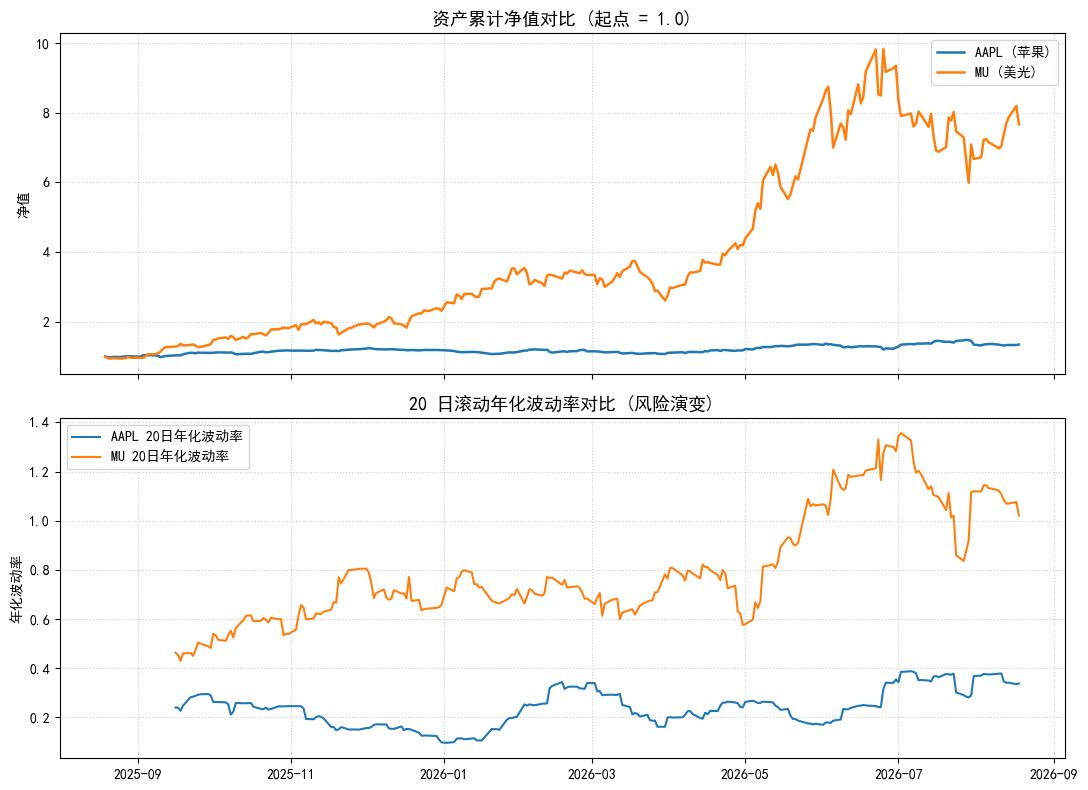

=== 风险收益核心统计表 ===
      累计收益率 (%)  年化波动率 (%)  日收益偏度 (Skewness)  日收益峰度 (Kurtosis)
AAPL      34.34      25.00             -0.41              3.19
MU       666.70      81.36              0.30              1.00


In [54]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 代理与中文配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 分别获取 AAPL 和 MU 历史数据（比批量 download 更稳定）
tickers = ['AAPL', 'MU']
close_dict = {}

for ticker in tickers:
    t = yf.Ticker(ticker)
    hist = t.history(period='1y')
    # 清洗时区索引
    hist.index = pd.to_datetime(hist.index.strftime('%Y-%m-%d'))
    close_dict[ticker] = hist['Close']

# 合并为 DataFrame
df = pd.DataFrame(close_dict).dropna()

# 3. 计算简单收益率
returns = df.pct_change().dropna()

# 4. 计算归一化净值 (起点设为 1.0)
cum_returns = (1 + returns).cumprod()

# 5. 计算 20 日滚动年化波动率
vol_20d = returns.rolling(20).std() * np.sqrt(252)

# 6. 可视化对比
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# 净值走势对比
axes[0].plot(cum_returns.index, cum_returns['AAPL'], label='AAPL (苹果)', color='tab:blue', lw=1.8)
axes[0].plot(cum_returns.index, cum_returns['MU'], label='MU (美光)', color='tab:orange', lw=1.8)
axes[0].set_title('资产累计净值对比 (起点 = 1.0)', fontsize=13)
axes[0].set_ylabel('净值')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# 滚动波动率对比
axes[1].plot(vol_20d.index, vol_20d['AAPL'], label='AAPL 20日年化波动率', color='tab:blue', lw=1.5)
axes[1].plot(vol_20d.index, vol_20d['MU'], label='MU 20日年化波动率', color='tab:orange', lw=1.5)
axes[1].set_title('20 日滚动年化波动率对比 (风险演变)', fontsize=13)
axes[1].set_ylabel('年化波动率')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

# 7. 打印两者的风险收益统计指标
stats = pd.DataFrame({
    '累计收益率 (%)': (cum_returns.iloc[-1] - 1) * 100,
    '年化波动率 (%)': (returns.std() * np.sqrt(252)) * 100,
    '日收益偏度 (Skewness)': returns.skew(),
    '日收益峰度 (Kurtosis)': returns.kurt()
})
print("=== 风险收益核心统计表 ===")
print(stats.round(2))

In [55]:
import os
import yfinance as yf
import pandas as pd

# 1. 代理与环境配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

# 2. 获取苹果（AAPL）近 1 年日线数据并清洗时区
ticker = yf.Ticker('AAPL')
df = ticker.history(period='1y')
df.index = pd.to_datetime(df.index.strftime('%Y-%m-%d'))

# 3. 计算简单日收益率
df['daily_return'] = df['Close'].pct_change()
rets = df['daily_return'].dropna()

# 4. 筛选绝对涨跌幅大于 5% 的交易日
threshold = 0.05
extreme_days = df[df['daily_return'].abs() >= threshold].copy()

# 5. 分离大涨与大跌
big_up = df[df['daily_return'] >= threshold]
big_down = df[df['daily_return'] <= -threshold]

# 6. 输出统计结果
print(f"=== 苹果 (AAPL) 近 1 年单日大波动 (|涨跌幅| >= 5%) 统计 ===")
print(f"总交易日天数:           {len(rets)} 天")
print(f"绝对涨跌幅 >= 5% 的总天数: {len(extreme_days)} 天 (占比: {len(extreme_days)/len(rets):.2%})")
print(f"  - 单日大涨 (>= +5%):    {len(big_up)} 天")
print(f"  - 单日大跌 (<= -5%):    {len(big_down)} 天")

if not extreme_days.empty:
    print("\n=== 具体交易日清单 ===")
    display_df = pd.DataFrame({
        '收盘价 ($)': extreme_days['Close'],
        '日收益率 (%)': extreme_days['daily_return'] * 100,
        '成交量 (万股)': extreme_days['Volume'] / 1e4
    })
    print(display_df.round(2))
else:
    print("\n近 1 年内未出现单日涨跌幅绝对值达到或超过 5% 的交易日。")

=== 苹果 (AAPL) 近 1 年单日大波动 (|涨跌幅| >= 5%) 统计 ===
总交易日天数:           251 天
绝对涨跌幅 >= 5% 的总天数: 2 天 (占比: 0.80%)
  - 单日大涨 (>= +5%):    0 天
  - 单日大跌 (<= -5%):    2 天

=== 具体交易日清单 ===
            收盘价 ($)  日收益率 (%)  成交量 (万股)
Date                                   
2026-06-25   274.91     -6.12  10701.37
2026-07-31   308.64     -7.35  13248.91


苹果 (AAPL): 获取到 251 个交易日数据
特斯拉 (TSLA): 获取到 251 个交易日数据
美光科技 (MU): 获取到 251 个交易日数据

✅ 图表已保存为 'daily_return_histogram.png'，可直接用于截图打卡！


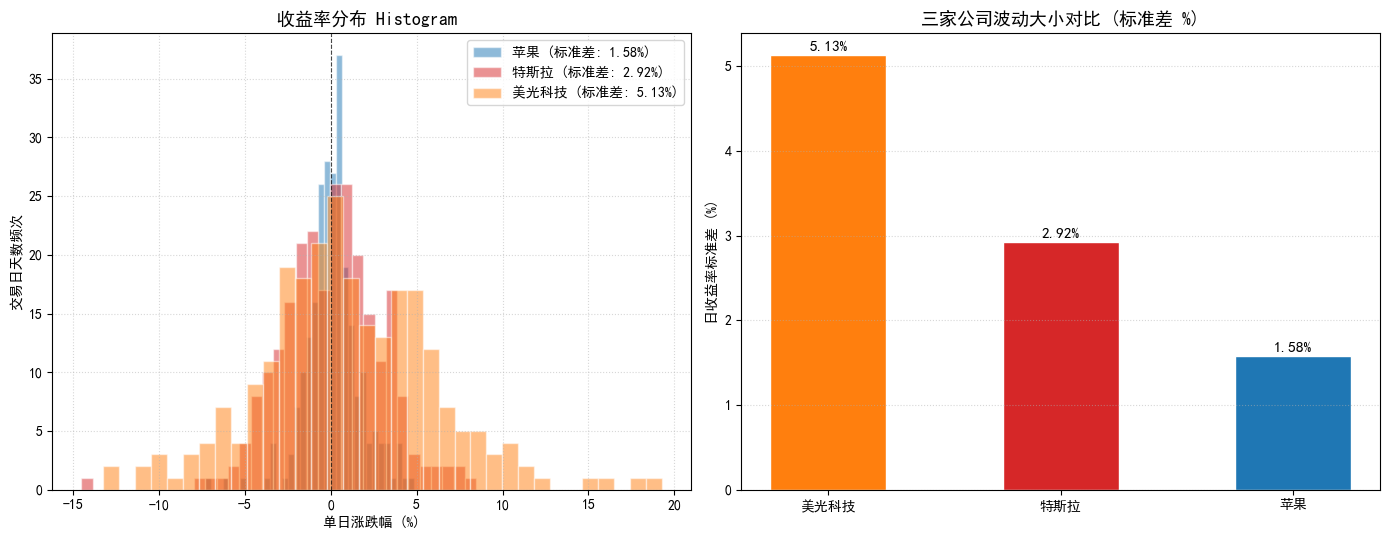

In [57]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 代理与画图中文配置
proxy_port = "7892"
os.environ['HTTP_PROXY'] = f'http://127.0.0.1:{proxy_port}'
os.environ['HTTPS_PROXY'] = f'http://127.0.0.1:{proxy_port}'

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 标的字典（将 NVDA 替换为你最熟悉的 MU 美光科技）
tickers = {
    'AAPL': '苹果',
    'TSLA': '特斯拉',
    'MU': '美光科技'
}

period = '1y'
all_rets = {}

# 3. 逐个稳定拉取数据并计算日收益率
for symbol, name in tickers.items():
    t = yf.Ticker(symbol)
    hist = t.history(period=period)
    hist.index = pd.to_datetime(hist.index.strftime('%Y-%m-%d'))
    all_rets[name] = hist['Close'].pct_change().dropna()
    print(f'{name} ({symbol}): 获取到 {len(all_rets[name])} 个交易日数据')

# 计算日收益率标准差（波动大小）
vol = pd.Series({name: s.std() for name, s in all_rets.items()}).sort_values(ascending=False)

# 4. 绘制用于打卡的【收益率 Histogram 分布图 + 波动对比图】
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = {'苹果': 'tab:blue', '特斯拉': 'tab:red', '美光科技': 'tab:orange'}

# --- 左图：收益率 Histogram (直方图) ---
for name, series in all_rets.items():
    axes[0].hist(series * 100, bins=35, alpha=0.5, label=f'{name} (标准差: {vol[name]:.2%})', color=colors[name], edgecolor='white')

axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].set_title('收益率分布 Histogram ', fontsize=13, fontweight='bold')
axes[0].set_xlabel('单日涨跌幅 (%)')
axes[0].set_ylabel('交易日天数频次')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

# --- 右图：波动率对比柱状图 ---
bar_colors = [colors[name] for name in vol.index]
axes[1].bar(vol.index, vol.values * 100, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('三家公司波动大小对比 (标准差 %)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('日收益率标准差 (%)')
axes[1].grid(True, axis='y', linestyle=':', alpha=0.5)

for i, v in enumerate(vol.values):
    axes[1].text(i, v * 100 + 0.05, f'{v:.2%}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()

# 保存高清打卡图到本地
plt.savefig('daily_return_histogram.png', dpi=300)
print("\n✅ 图表已保存为 'daily_return_histogram.png'，可直接用于截图打卡！")
plt.show()